In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df=pd.read_csv("/content/drive/MyDrive/Superstore_Sales_Dataset.csv")

In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [16]:
df.shape

(9800, 18)

In [17]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [19]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df["Order Date"].dtype

dtype('O')

In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"],format="%d/%m/%Y")

In [23]:
df["Order Date"].head(10)

,Order Date
0,2017-11-08
1,2017-11-08
2,2017-06-12
3,2016-10-11
4,2016-10-11
5,2015-06-09
6,2015-06-09
7,2015-06-09
8,2015-06-09
9,2015-06-09


In [25]:
df["Order Date"].dtype

dtype('<M8[ns]')

In [26]:
df = df.sort_values("Order Date")

In [27]:
df["Order Date"]

,Order Date
7980,2015-01-03
741,2015-01-04
740,2015-01-04
739,2015-01-04
1759,2015-01-05
...,...
1297,2018-12-30
906,2018-12-30
645,2018-12-30
908,2018-12-30


In [28]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)
#rest_index() again converts it into pandas DataFrame

In [29]:
daily_sales

,Order Date,Sales
0,2015-01-03,16.4480
1,2015-01-04,288.0600
2,2015-01-05,19.5360
3,2015-01-06,4407.1000
4,2015-01-07,87.1580
...,...,...
1225,2018-12-26,814.5940
1226,2018-12-27,177.6360
1227,2018-12-28,1657.3508
1228,2018-12-29,2915.5340


In [30]:
daily_sales.shape

(1230, 2)

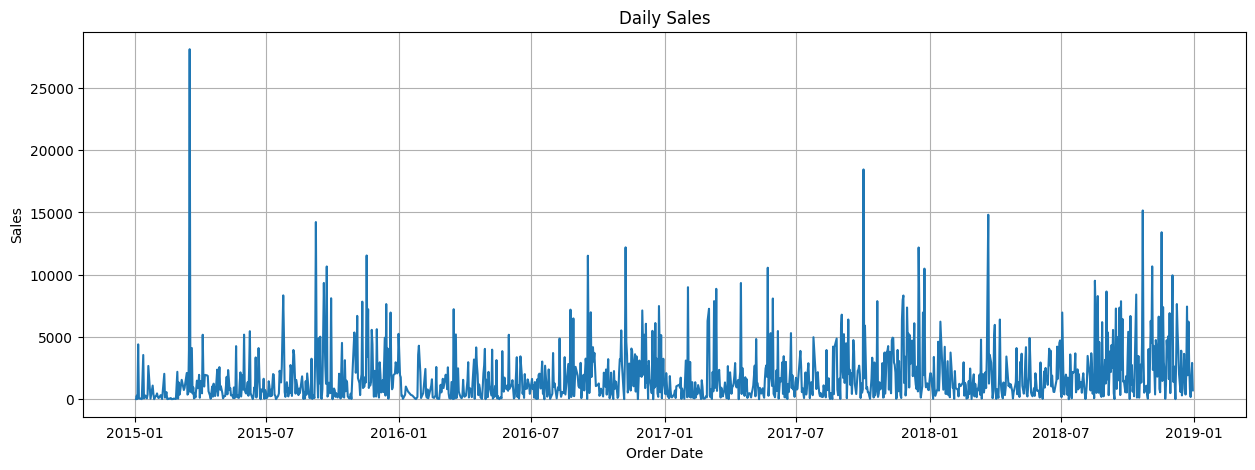

In [31]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Order Date"],
    daily_sales["Sales"]
)

plt.title("Daily Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

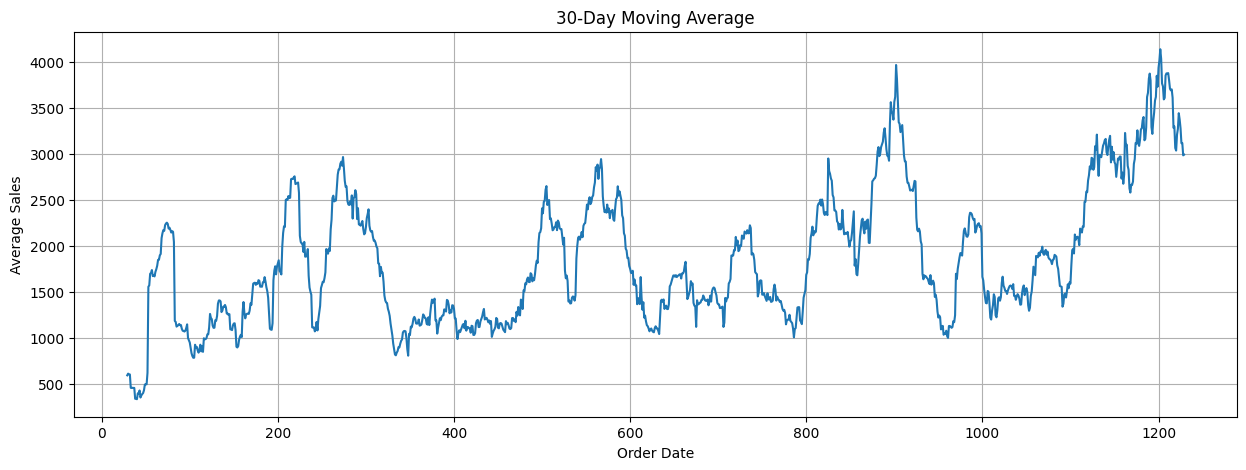

In [32]:
plt.figure(figsize=(15,5))

daily_sales["Sales"].rolling(window=30).mean().plot()

plt.title("30-Day Moving Average")
plt.xlabel("Order Date")
plt.ylabel("Average Sales")

plt.grid(True)
plt.show()

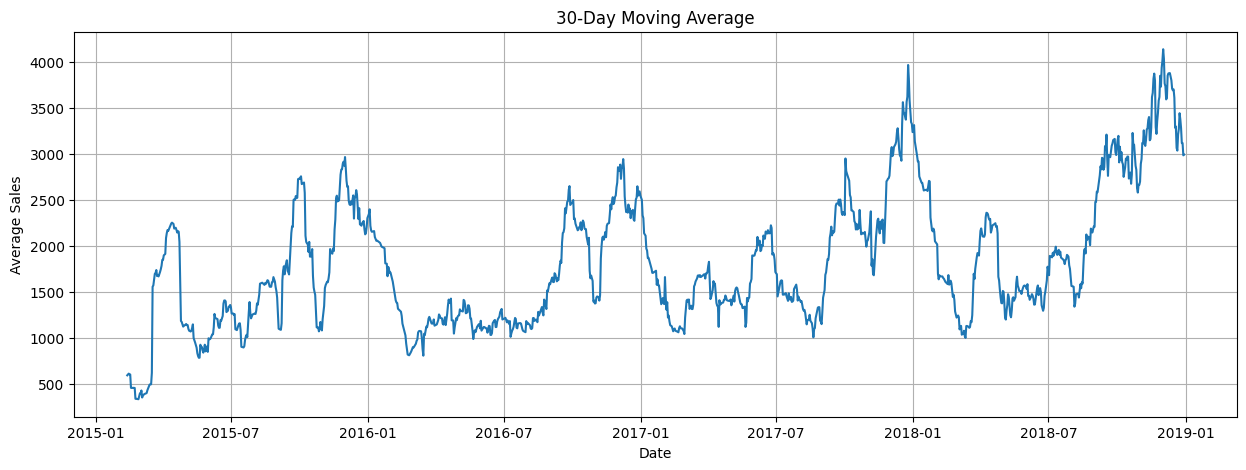

In [33]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Order Date"],
    daily_sales["Sales"].rolling(window=30).mean()
)

plt.title("30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Average Sales")

plt.grid(True)
plt.show()

In [34]:
 daily_sales


,Order Date,Sales
0,2015-01-03,16.4480
1,2015-01-04,288.0600
2,2015-01-05,19.5360
3,2015-01-06,4407.1000
4,2015-01-07,87.1580
...,...,...
1225,2018-12-26,814.5940
1226,2018-12-27,177.6360
1227,2018-12-28,1657.3508
1228,2018-12-29,2915.5340


In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_sales = scaler.fit_transform( daily_sales[["Sales"]])

In [38]:
scaled_sales

array([[0.00051319],
       [0.01017748],
       [0.00062306],
       ...,
       [0.05889856],
       [0.10366629],
       [0.02532549]])

In [39]:
print(scaled_sales.shape)

(1230, 1)


# **Create the Sliding Window Function**

In [40]:
import numpy as np

def create_sequences(data, window_size):

    X = []
    y = []

    for i in range(len(data) - window_size):

        X.append(data[i:i + window_size])

        y.append(data[i + window_size])

    return np.array(X), np.array(y)

In [41]:
window_size = 30

X, y = create_sequences(
    scaled_sales,
    window_size
)

In [42]:
X

array([[[0.00051319],
        [0.01017748],
        [0.00062306],
        ...,
        [0.00044601],
        [0.07263467],
        [0.00453814]],

       [[0.01017748],
        [0.00062306],
        [0.15673807],
        ...,
        [0.07263467],
        [0.00453814],
        [0.02044858]],

       [[0.00062306],
        [0.15673807],
        [0.00302914],
        ...,
        [0.00453814],
        [0.02044858],
        [0.00068796]],

       ...,

       [[0.05750745],
        [0.24589913],
        [0.01742994],
        ...,
        [0.09595914],
        [0.02891222],
        [0.00624846]],

       [[0.24589913],
        [0.01742994],
        [0.23637538],
        ...,
        [0.02891222],
        [0.00624846],
        [0.05889856]],

       [[0.01742994],
        [0.23637538],
        [0.18961792],
        ...,
        [0.00624846],
        [0.05889856],
        [0.10366629]]])

In [43]:
y

array([[0.02044858],
       [0.00068796],
       [0.0002496 ],
       ...,
       [0.05889856],
       [0.10366629],
       [0.02532549]])

In [44]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (1200, 30, 1)
y Shape : (1200, 1)


In [48]:
for i in range(3):

    print("="*50)

    print(f"Sample {i+1}")

    print("\nInput (30 Previous Days):")

    print(X[i].flatten())

    print("\nTarget (Next Day):")

    print(y[i][0])

Sample 1

Input (30 Previous Days):
[5.13188350e-04 1.01774825e-02 6.23063246e-04 1.56738069e-01
 3.02913845e-03 1.37055412e-03 1.87886784e-03 2.81625583e-04
 1.26376412e-01 2.13256214e-03 5.26335621e-03 1.06010417e-02
 2.23589009e-03 1.33987952e-02 9.50675814e-02 1.35404442e-03
 3.89694731e-02 1.51093994e-02 6.77111163e-05 8.48523828e-03
 1.02702072e-02 1.66119955e-02 7.45857693e-03 3.38331419e-03
 4.70949850e-03 1.16879776e-02 6.34395874e-03 4.46010952e-04
 7.26346716e-02 4.53813920e-03]

Target (Next Day):
0.02044857920693738
Sample 2

Input (30 Previous Days):
[1.01774825e-02 6.23063246e-04 1.56738069e-01 3.02913845e-03
 1.37055412e-03 1.87886784e-03 2.81625583e-04 1.26376412e-01
 2.13256214e-03 5.26335621e-03 1.06010417e-02 2.23589009e-03
 1.33987952e-02 9.50675814e-02 1.35404442e-03 3.89694731e-02
 1.51093994e-02 6.77111163e-05 8.48523828e-03 1.02702072e-02
 1.66119955e-02 7.45857693e-03 3.38331419e-03 4.70949850e-03
 1.16879776e-02 6.34395874e-03 4.46010952e-04 7.26346716e-02
 4

In [49]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [50]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (960, 30, 1)
X_test  : (240, 30, 1)
y_train : (960, 1)
y_test  : (240, 1)


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model = Sequential()

In [52]:
model.add(
    SimpleRNN(
        units=64,
        activation="tanh",
        input_shape=(30,1)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
model.add(
    Dense(
        32,
        activation="relu"
    )
)

In [54]:
model.add(
    Dense(1)
)

In [55]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [57]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [58]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0083 - mae: 0.0603 - val_loss: 0.0083 - val_mae: 0.0732
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0067 - mae: 0.0525 - val_loss: 0.0081 - val_mae: 0.0636
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0063 - mae: 0.0515 - val_loss: 0.0083 - val_mae: 0.0623
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0063 - mae: 0.0511 - val_loss: 0.0075 - val_mae: 0.0631
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0062 - mae: 0.0512 - val_loss: 0.0081 - val_mae: 0.0629
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0061 - mae: 0.0504 - val_loss: 0.0081 - val_mae: 0.0620
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - mae: 0.0488 - val_loss: 0.0080 - val_mae: 0.0631
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0059 - mae: 0.0493 - val_loss: 0.0077 - val_mae: 0.0629
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.00

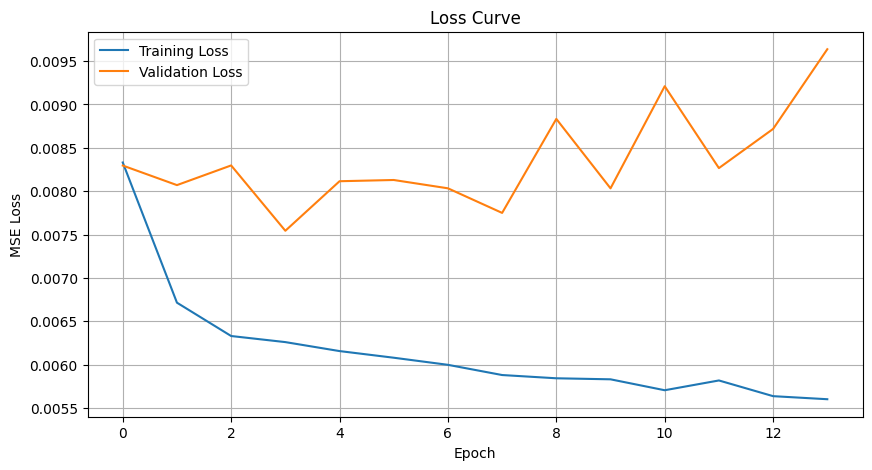

In [59]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()

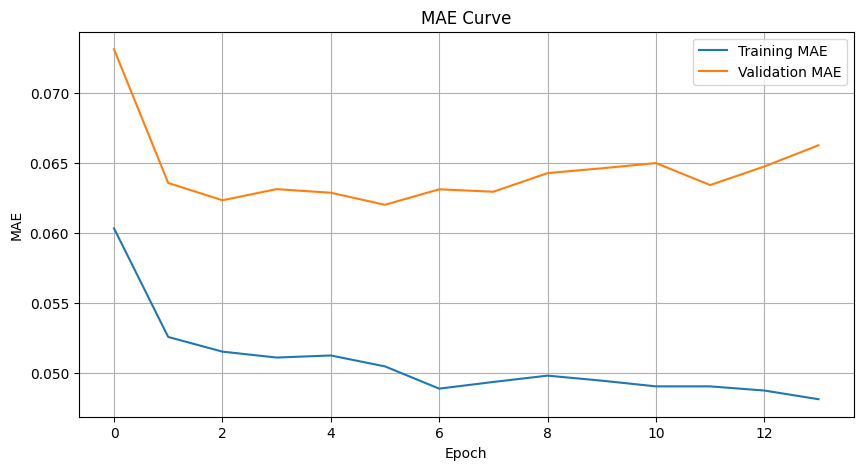

In [60]:
plt.figure(figsize=(10,5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.title("MAE Curve")
plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend()
plt.grid(True)

plt.show()

In [61]:
predictions = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step


In [63]:
print(predictions.shape)

(240, 1)


In [64]:
print(predictions[:5])

[[0.052068  ]
 [0.05446191]
 [0.07622737]
 [0.04520789]
 [0.08039204]]


In [65]:
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

In [66]:
print(predictions[:5])

[[1465.38  ]
 [1532.66  ]
 [2144.3718]
 [1272.5787]
 [2261.4185]]


In [67]:
comparison = pd.DataFrame({
    "Actual": y_test_actual.flatten(),
    "Predicted": predictions.flatten()
})

comparison.head(10)

,Actual,Predicted
0,1345.824,1465.380005
1,652.930,1532.660034
2,332.338,2144.371826
3,944.429,1272.578735
4,3431.459,2261.418457
5,1053.614,1382.918457
6,1254.564,2314.577148
7,947.692,1223.620728
8,1199.222,1283.297852
9,928.558,2314.384033


In [68]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [69]:
mae = mean_absolute_error(
    y_test_actual,
    predictions
)

print("MAE :", mae)

MAE : 1774.3464196695963


In [70]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

print("RMSE :", rmse)

RMSE : 2440.9414698263517


In [71]:
r2 = r2_score(
    y_test_actual,
    predictions
)

print("R² :", r2)

R² : 0.014223568109770213


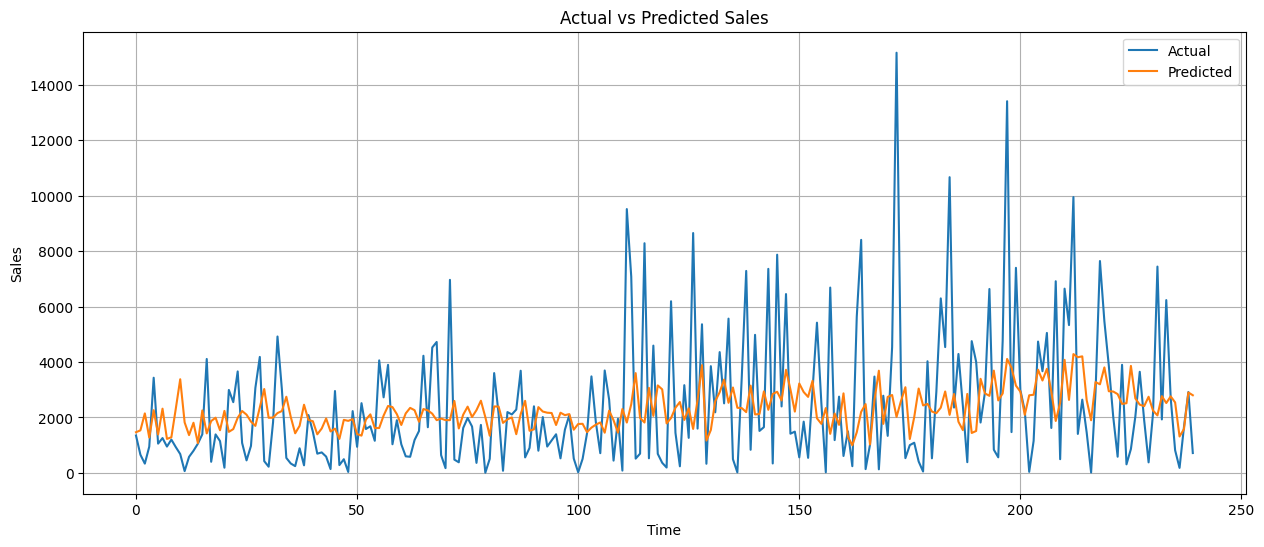

In [72]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [74]:
model = Sequential()

model.add(
    LSTM(
        units=64,
        activation="tanh",
        input_shape=(30,1)
    )
)

model.add(
    Dense(
        units=32,
        activation="relu"
    )
)

model.add(
    Dense(1)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [75]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [77]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [78]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0068 - mae: 0.0529 - val_loss: 0.0075 - val_mae: 0.0626
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0064 - mae: 0.0516 - val_loss: 0.0083 - val_mae: 0.0605
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0064 - mae: 0.0511 - val_loss: 0.0075 - val_mae: 0.0623
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0063 - mae: 0.0514 - val_loss: 0.0079 - val_mae: 0.0606
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0063 - mae: 0.0514 - val_loss: 0.0079 - val_mae: 0.0605
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0063 - mae: 0.0506 - val_loss: 0.0079 - val_mae: 0.0605
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0064 - mae: 0.0509 - val_loss: 0.0078 - val_mae: 0.0606
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0063 - mae: 0.0512 - val_loss: 0.0079 - val_mae: 0.0605
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

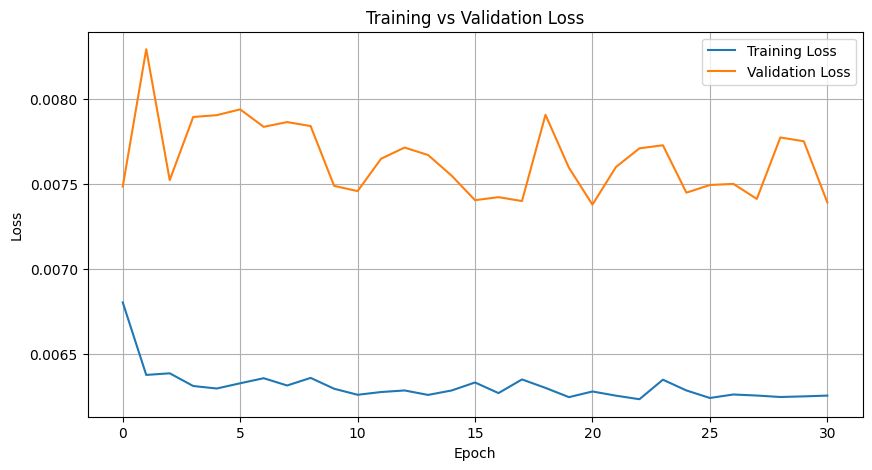

In [79]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

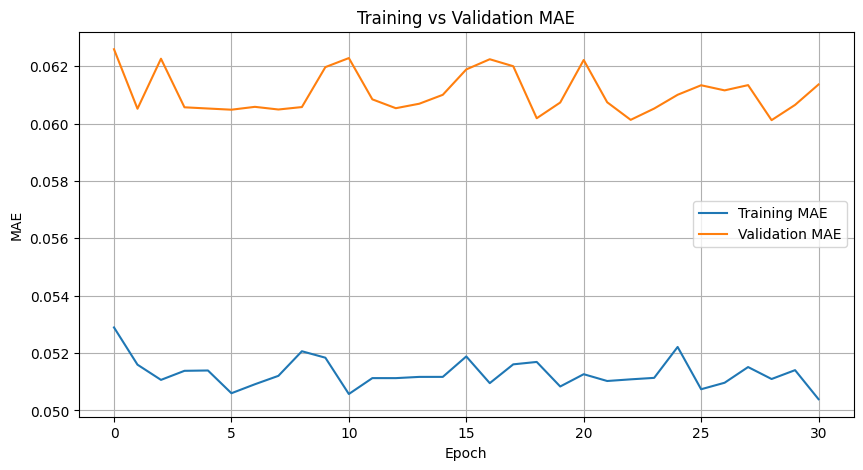

In [80]:
plt.figure(figsize=(10,5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.show()

In [81]:
predictions = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


In [82]:
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

In [83]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae = mean_absolute_error(
    y_test_actual,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

r2 = r2_score(
    y_test_actual,
    predictions
)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 1748.656189614258
RMSE : 2414.2203352207653
R² Score : 0.03568814350678784


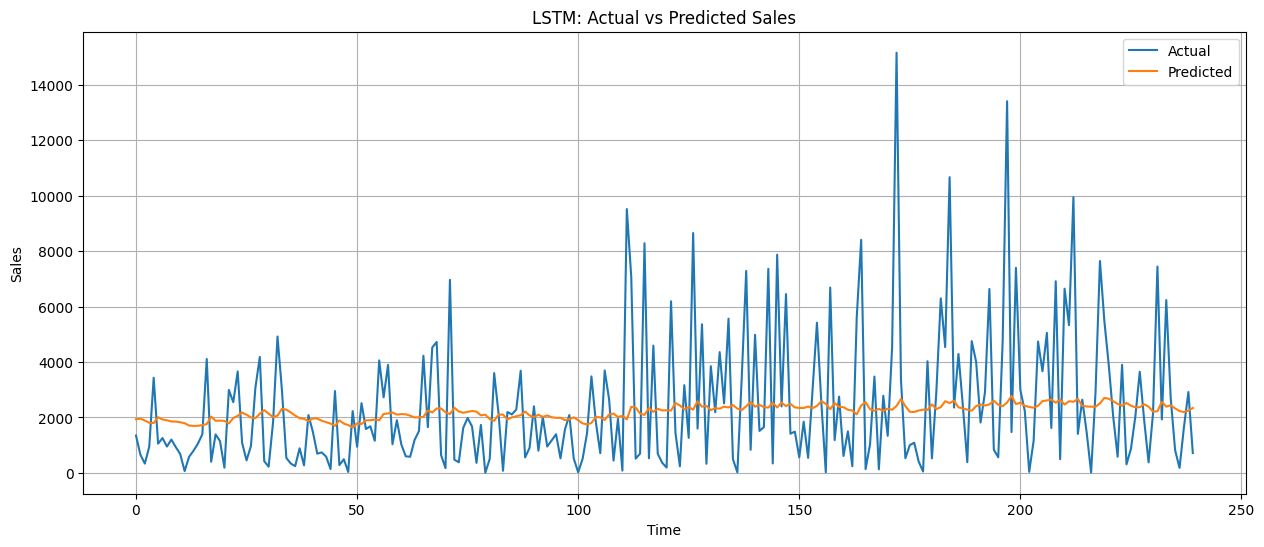

In [84]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.title("LSTM: Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()